# 🔍 Error Analysis

## Objective

After training and evaluating the model, it is important to understand where the model makes mistakes.

Error analysis helps identify:

- Difficult prediction scenarios
- Model limitations
- Potential improvements
- Future feature engineering opportunities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/train_featured.csv")

X = df.drop("trip_duration", axis=1)
y = df["trip_duration"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [3]:
model = joblib.load("../models/best_model.pkl")

predictions = model.predict(X_test)

In [4]:
results = X_test.copy()

results["Actual"] = y_test.values

results["Predicted"] = predictions

results["Absolute_Error"] = np.abs(
    results["Actual"] - results["Predicted"]
)

results.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_hour,pickup_day,pickup_month,...,is_rush_hour,is_night,haversine_distance_km,manhattan_distance_km,longitude_difference,latitude_difference,bearing,Actual,Predicted,Absolute_Error
1197618,2,5,-73.969109,40.790768,-73.987686,40.762241,0,20,11,6,...,0,0,3.536736,4.735947,-0.018578,-0.028526,206.256862,621,726.722961,105.722961
864175,2,2,-74.002533,40.725014,-73.782387,40.644218,0,16,12,5,...,1,0,20.622523,27.535526,0.220146,-0.080795,115.754321,5963,5508.747559,454.252441
1368093,1,1,-73.991867,40.750183,-74.007286,40.726894,0,11,29,2,...,0,0,2.897167,3.888441,-0.015419,-0.023289,206.645904,524,775.390015,251.390015
253941,2,5,-73.988800,40.731380,-73.991333,40.750309,0,1,24,4,...,0,1,2.115547,2.318186,-0.002533,0.018929,354.211446,654,647.171143,6.828857
1189118,1,1,-73.963036,40.776581,-73.976974,40.787411,0,15,22,2,...,0,0,1.681529,2.377940,-0.013939,0.010830,315.742349,554,609.548706,55.548706


# Distribution of Prediction Errors

plt.figure(figsize=(10,5))

sns.histplot(
    results["Absolute_Error"],
    bins=60
)

plt.title("Distribution of Absolute Errors")

plt.xlabel("Absolute Error")

plt.show()

### Observation

Most predictions have relatively low error.

However, a small number of trips produce significantly larger prediction errors, indicating challenging cases for the model.

# Actual vs Predicted

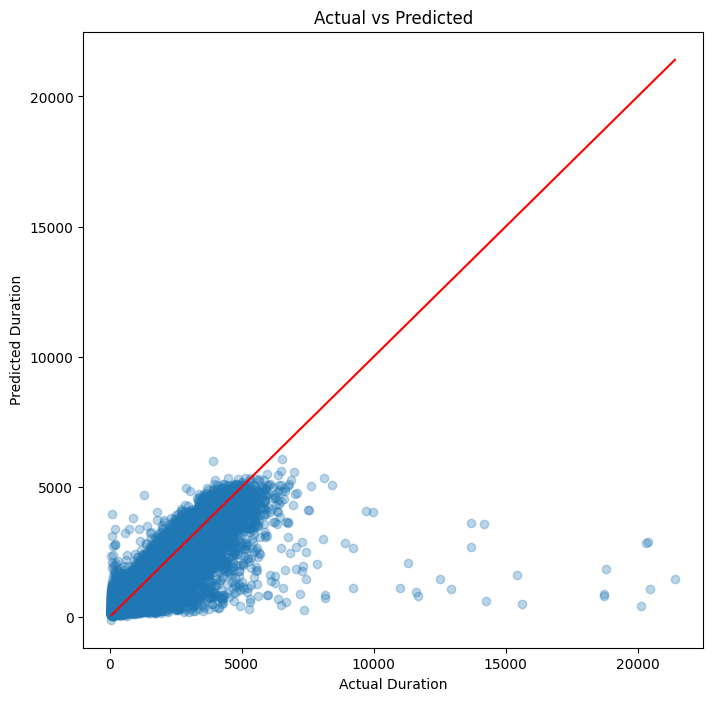

In [7]:
plt.figure(figsize=(8,8))

plt.scatter(
    results["Actual"],
    results["Predicted"],
    alpha=0.3
)

plt.plot(
    [results["Actual"].min(), results["Actual"].max()],
    [results["Actual"].min(), results["Actual"].max()],
    color="red"
)

plt.xlabel("Actual Duration")

plt.ylabel("Predicted Duration")

plt.title("Actual vs Predicted")

plt.show()

### Observation

Predictions close to the red diagonal represent accurate predictions.

Points farther away from the diagonal indicate larger prediction errors.

# Top 20 Largest Errors

In [8]:
largest_errors = results.sort_values(
    by="Absolute_Error",
    ascending=False
).head(20)

largest_errors

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_hour,pickup_day,pickup_month,...,is_rush_hour,is_night,haversine_distance_km,manhattan_distance_km,longitude_difference,latitude_difference,bearing,Actual,Predicted,Absolute_Error
838661,2,2,-73.781998,40.644691,-73.824081,40.718201,0,18,31,1,...,1,0,8.910946,11.724484,-0.042084,0.073509,336.545647,21411,1450.312012,19960.687988
510042,2,1,-73.961685,40.767719,-73.969376,40.763561,0,18,21,6,...,1,0,0.795766,1.110000,-0.007690,-0.004158,234.480663,20129,423.901031,19705.098969
126281,2,1,-73.993637,40.752121,-73.967827,40.798859,0,18,29,2,...,1,0,5.633133,7.371110,0.025810,0.046738,22.685987,20470,1078.319824,19391.680176
818085,2,1,-73.975212,40.753773,-73.986107,40.758072,0,18,22,4,...,1,0,1.034716,1.395740,-0.010895,0.004299,297.520193,18719,801.016724,17917.983276
432096,2,1,-73.873062,40.774101,-73.889130,40.751335,0,18,3,5,...,1,0,2.870469,3.884470,-0.016068,-0.022766,208.132418,18723,896.216064,17826.783936
1393381,2,1,-73.986107,40.760033,-73.789276,40.646515,0,9,2,2,...,1,0,20.847761,29.200601,0.196831,-0.113518,127.198110,20400,2883.116211,17516.883789
560172,2,2,-73.789551,40.647408,-73.978569,40.761642,0,18,24,4,...,1,0,20.376918,28.649284,-0.189018,0.114235,308.624178,20322,2830.384521,17491.615479
1254685,2,2,-73.996384,40.716461,-73.962509,40.778980,0,18,11,6,...,1,0,7.514692,9.806743,0.033875,0.062519,22.306268,18794,1852.872559,16941.127441
567880,2,1,-73.982689,40.766842,-73.984039,40.777840,0,13,22,6,...,0,0,1.228172,1.336622,-0.001350,0.010998,354.687829,15617,494.883392,15122.116608
629208,2,1,-73.870949,40.773830,-73.994087,40.745090,0,19,22,3,...,1,0,10.852570,13.564874,-0.123138,-0.028740,252.914568,15418,1629.353271,13788.646729


### Observation

These trips are the most difficult for the model.

Further investigation may reveal common characteristics such as long travel distances, unusual pickup times, or rare routes.

# Error by Pickup Hour

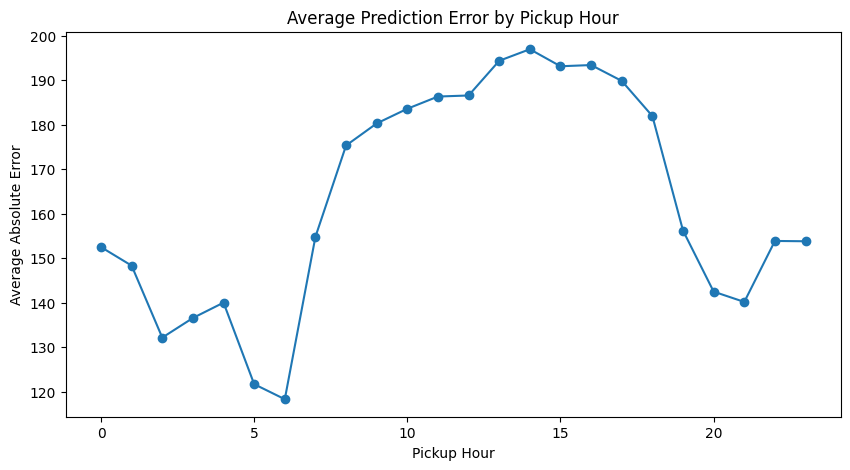

In [9]:
hour_error = results.groupby("pickup_hour")["Absolute_Error"].mean()

plt.figure(figsize=(10,5))

hour_error.plot(marker="o")

plt.title("Average Prediction Error by Pickup Hour")

plt.xlabel("Pickup Hour")

plt.ylabel("Average Absolute Error")

plt.show()

### Observation

Prediction error varies across different hours of the day.

Higher errors during peak traffic periods may indicate increased travel uncertainty.

# Error by Weekend

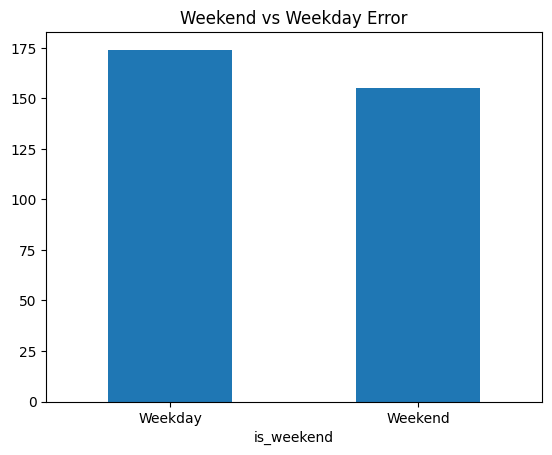

In [11]:
weekend_error = results.groupby("is_weekend")["Absolute_Error"].mean()

weekend_error.plot(kind="bar")

plt.title("Weekend vs Weekday Error")

plt.xticks([0,1],["Weekday","Weekend"], rotation=0)

plt.show()

### Observation

Comparing weekend and weekday prediction errors helps determine whether travel behavior differs significantly across the week.

# Error vs Distance